# Action0 SNN training foundation

This notebook connects the selected signed or `AbsRectify` Action0 padded producer output to the three disjoint dataset splits, then renders the pre-training label and valid-frame visualizations. Training uses the same selected representation.

In [68]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import snn

from snn.action0_dataset import (
    Action0SegmentDataset,
    INPUT_CHANNEL_COUNT,
    discover_class_to_idx,
    load_padding_dataset_metadata,
    resolve_dataset_root,
    resolve_segmentation_root,
)
from snn.train_action0 import (
    _validate_sampling_rate,
    _validate_split_padded_lengths,
    _validate_user_splits,
)

In [ ]:
# Keep every notebook-owned setting in this one configuration cell.
POST_ENCODE_TRANSFORM = "AbsRectify"
_POST_ENCODE_ROOTS = {
    "None": Path(snn.__file__).resolve().parent.parent / "outputs" / "action0_pipeline",
    "AbsRectify": Path(snn.__file__).resolve().parent.parent / "outputs" / "action0_rectified",
}
if POST_ENCODE_TRANSFORM not in _POST_ENCODE_ROOTS:
    raise ValueError(
        "POST_ENCODE_TRANSFORM must be exactly one of: \"None\", \"AbsRectify\"; "
        f"got {POST_ENCODE_TRANSFORM!r}"
    )
PIPELINE_ROOT = _POST_ENCODE_ROOTS[POST_ENCODE_TRANSFORM]
# The producer records the signed choice as JSON null; retain the config
# string above so rerunning the notebook remains explicit and strict.
selected_post_encode_transform = (
    None if POST_ENCODE_TRANSFORM == "None" else POST_ENCODE_TRANSFORM
)
REPOSITORY_ROOT = Path(snn.__file__).resolve().parent.parent
FIGURE_DIR = REPOSITORY_ROOT / "notebooks" / "figures"
DATASET_VARIANT = "lowpass"
SAMPLE_RATE = 200.0
TRAIN_USERS = [
    "user_0",
    "user_1",
    "user_2",
    "user_3",
    "user_4",
    "user_5",
    "user_6",
    "user_7",
    "user_8",
    "user_9",
    "user_10",
    "user_11",
    "user_12",
    "user_13",
    "user_14",
]
VAL_USERS = ["user_15", "user_16", "user_17"]
TEST_USERS = ["user_18", "user_19", "user_20"]

NEURONS_NETWORK = [80, 80,80]
SHIFT_SYN = 4
SHIFT_MEM = 2
BATCH_SIZE = 128
NUM_EPOCHS = 30
LEARNING_RATE = 5e-4
SPIKE_REGULARIZATION = 0.0
RANDOM_SEED = 12345
NUM_SELECTED_LABELS = 10  # randomly select 10 common labels
LABEL_SELECTION_SEED = RANDOM_SEED
SAVE_FIGURES = False
USE_GPU = True

## Load the producer-published padded dataset

The data foundation uses the producer's `segmentation_padded` packages directly. `POST_ENCODE_TRANSFORM` selects one of the two pre-published roots before the dataset variant, metadata, class map, splits, visualizations, and training are constructed. The shared label mapping is discovered once from the selected variant and passed to every split.

In [70]:
import torch
from torch.utils.data import Dataset


_validate_user_splits(TRAIN_USERS, VAL_USERS, TEST_USERS)

dataset_root = resolve_dataset_root(PIPELINE_ROOT, DATASET_VARIANT)
segmentation_root = resolve_segmentation_root(dataset_root)

if not segmentation_root.is_dir():
    raise FileNotFoundError(
        f"missing padded root for POST_ENCODE_TRANSFORM={POST_ENCODE_TRANSFORM!r}: "
        f"{segmentation_root}. Run the matching Action0 producer first."
    )

producer_metadata = load_padding_dataset_metadata(segmentation_root)

_validate_sampling_rate(
    cli_sampling_rate=SAMPLE_RATE,
    producer_sampling_rate=producer_metadata.sampling_rate_hz,
)


# ============================================================
# 1. 先得到 the canonical full-label mapping
# ============================================================

full_class_to_idx = discover_class_to_idx(segmentation_root)

print(f"Total available labels: {len(full_class_to_idx)}")


# ============================================================
# 2. 先建立完整 dataset
# ============================================================

full_train_dataset = Action0SegmentDataset(
    segmentation_root,
    TRAIN_USERS,
    full_class_to_idx,
)

full_val_dataset = Action0SegmentDataset(
    segmentation_root,
    VAL_USERS,
    full_class_to_idx,
)

full_test_dataset = Action0SegmentDataset(
    segmentation_root,
    TEST_USERS,
    full_class_to_idx,
)


# ============================================================
# 3. 从三份 full split 的正样本 label 交集中随机选择
# ============================================================

full_split_datasets = {
    "train": full_train_dataset,
    "validation": full_val_dataset,
    "test": full_test_dataset,
}
positive_labels_by_split = {
    split_name: {
        label
        for label, count in dataset.class_distribution.items()
        if int(count) > 0
    }
    for split_name, dataset in full_split_datasets.items()
}
common_positive_labels = sorted(
    set.intersection(*positive_labels_by_split.values())
)

if NUM_SELECTED_LABELS <= 0:
    raise ValueError(
        f"NUM_SELECTED_LABELS must be positive; got {NUM_SELECTED_LABELS}"
    )
if NUM_SELECTED_LABELS > len(common_positive_labels):
    raise ValueError(
        f"NUM_SELECTED_LABELS={NUM_SELECTED_LABELS} "
        "exceeds the common positive-label intersection: "
        f"{len(common_positive_labels)}"
    )

rng = np.random.default_rng(LABEL_SELECTION_SEED)
selected_labels = rng.choice(
    common_positive_labels,
    size=NUM_SELECTED_LABELS,
    replace=False,
).tolist()
selected_labels = sorted(str(label) for label in selected_labels)

print()
print(f"Randomly selected {NUM_SELECTED_LABELS} common positive labels:")
for label in selected_labels:
    print(f"  {label}")


# ============================================================
# 4. 建立 shared contiguous selected mapping
# ============================================================

class_to_idx = {
    label: new_idx
    for new_idx, label in enumerate(selected_labels)
}

print()
print("New class mapping:")
print(class_to_idx)


# Canonical full-label index -> selected-label index
old_idx_to_new_idx = {
    full_class_to_idx[label]: class_to_idx[label]
    for label in selected_labels
}


# ============================================================
# 5. Dataset wrapper
#
# 作用：
#   (1) 只保留 selected_labels
#   (2) 原始 label index -> 0~9
# ============================================================

class SelectedLabelDataset(Dataset):
    """Filter one canonical split and remap labels contiguously."""

    def __init__(self, base_dataset, selected_labels, old_idx_to_new_idx):
        self.base_dataset = base_dataset
        self.selected_labels = tuple(str(label) for label in selected_labels)
        self.class_to_idx = {
            label: index for index, label in enumerate(self.selected_labels)
        }
        self.old_idx_to_new_idx = dict(old_idx_to_new_idx)
        if not self.selected_labels:
            raise ValueError("selected_labels must not be empty")
        if set(self.old_idx_to_new_idx) != {
            full_class_to_idx[label] for label in self.selected_labels
        }:
            raise ValueError("selected mapping does not cover exactly the selected labels")

        self.indices = []
        for base_idx in range(len(base_dataset)):
            _, old_label, _ = base_dataset[base_idx]
            old_label_idx = int(old_label.item())
            if old_label_idx in self.old_idx_to_new_idx:
                self.indices.append(base_idx)

        self.class_distribution = {
            label: int(base_dataset.class_distribution.get(label, 0))
            for label in self.selected_labels
        }
        self.padded_length = int(base_dataset.padded_length)
        retained_count = sum(self.class_distribution.values())
        if retained_count != len(self.indices):
            raise AssertionError(
                "selected class counts must equal retained sample count: "
                f"{retained_count} != {len(self.indices)}"
            )
        if not self.indices:
            raise ValueError("selected split must contain at least one sample")
        missing = [
            label for label, count in self.class_distribution.items() if count <= 0
        ]
        if missing:
            raise ValueError(
                "selected labels must have positive coverage in every split: "
                f"{missing}"
            )
        for sample_index in self.indices:
            features, label, valid_mask = base_dataset[sample_index]
            if tuple(features.shape) != (self.padded_length, INPUT_CHANNEL_COUNT):
                raise AssertionError(
                    "selected samples must have shape (T, 15): "
                    f"{tuple(features.shape)}"
                )
            if label.ndim != 0 or label.dtype != torch.long:
                raise AssertionError("selected labels must be scalar torch.long tensors")
            if tuple(valid_mask.shape) != (self.padded_length,) or valid_mask.dtype != torch.bool:
                raise AssertionError("selected valid masks must be (T,) torch.bool tensors")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        features, old_label, valid_mask = self.base_dataset[self.indices[idx]]
        old_label_idx = int(old_label.item())
        new_label_idx = self.old_idx_to_new_idx[old_label_idx]
        new_label = torch.tensor(new_label_idx, dtype=torch.long)
        if tuple(features.shape) != (self.padded_length, INPUT_CHANNEL_COUNT):
            raise AssertionError("selected sample feature shape changed")
        if new_label.ndim != 0 or new_label.dtype != torch.long:
            raise AssertionError("remapped label must be scalar torch.long")
        if tuple(valid_mask.shape) != (self.padded_length,) or valid_mask.dtype != torch.bool:
            raise AssertionError("selected valid mask shape or dtype changed")
        return features, new_label, valid_mask


# ============================================================
# 6. 得到真正用于 train / val / test 的 selected-label datasets
# ============================================================

train_dataset = SelectedLabelDataset(
    full_train_dataset,
    selected_labels,
    old_idx_to_new_idx,
)

val_dataset = SelectedLabelDataset(
    full_val_dataset,
    selected_labels,
    old_idx_to_new_idx,
)

test_dataset = SelectedLabelDataset(
    full_test_dataset,
    selected_labels,
    old_idx_to_new_idx,
)


_validate_split_padded_lengths(
    producer_metadata,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
)


for split_name, dataset in (
    ("train", train_dataset),
    ("validation", val_dataset),
    ("test", test_dataset),
):
    if len(dataset) == 0:
        raise AssertionError(f"{split_name} selected split is empty")
    if tuple(dataset.class_distribution) != tuple(selected_labels):
        raise AssertionError(
            f"{split_name} does not expose exactly the selected labels: "
            f"{tuple(dataset.class_distribution)}"
        )
    if any(count <= 0 for count in dataset.class_distribution.values()):
        raise AssertionError(f"{split_name} selected labels lack positive coverage")
    if sum(dataset.class_distribution.values()) != len(dataset):
        raise AssertionError(f"{split_name} retained counts are inconsistent")

sample_features, sample_label, sample_valid_mask = train_dataset[0]
if tuple(sample_features.shape) != (train_dataset.padded_length, INPUT_CHANNEL_COUNT):
    raise AssertionError("selected samples must have shape (T, 15)")
if sample_label.ndim != 0 or sample_label.dtype != torch.long:
    raise AssertionError("selected labels must be scalar torch.long tensors")
if tuple(sample_valid_mask.shape) != (train_dataset.padded_length,) or sample_valid_mask.dtype != torch.bool:
    raise AssertionError("selected masks must be (T,) torch.bool tensors")

print()
print("=" * 60)
print("Selected-label datasets")
print("=" * 60)

print(f"Common positive-label intersection: {common_positive_labels}")
print(f"Selection seed: {LABEL_SELECTION_SEED}")
print(f"Selected labels ({len(selected_labels)}): {selected_labels}")
print(f"Selected class mapping: {class_to_idx}")
print(f"train samples: {len(train_dataset)}")
print(f"val samples:   {len(val_dataset)}")
print(f"test samples:  {len(test_dataset)}")

Total available labels: 52

Randomly selected 10 common positive labels:
  J
  K
  O
  U
  e
  f
  h
  j
  m
  y

New class mapping:
{'J': 0, 'K': 1, 'O': 2, 'U': 3, 'e': 4, 'f': 5, 'h': 6, 'j': 7, 'm': 8, 'y': 9}

Selected-label datasets
Common positive-label intersection: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Selection seed: 12345
Selected labels (10): ['J', 'K', 'O', 'U', 'e', 'f', 'h', 'j', 'm', 'y']
Selected class mapping: {'J': 0, 'K': 1, 'O': 2, 'U': 3, 'e': 4, 'f': 5, 'h': 6, 'j': 7, 'm': 8, 'y': 9}
train samples: 334
val samples:   66
test samples:  58


In [71]:
print(f"Dataset variant: {DATASET_VARIANT}")
print(f"POST_ENCODE_TRANSFORM selection: {POST_ENCODE_TRANSFORM!r}")
print(
    f"Producer post_encode_transform metadata value: {selected_post_encode_transform!r}"
)
print(f"Selected pipeline root: {PIPELINE_ROOT}")
print(f"Resolved padded root: {segmentation_root}")
print("Change POST_ENCODE_TRANSFORM and rerun from the data-loading cell onward.")
print("Producer metadata:")
print(f"  input_kind: {producer_metadata.input_kind}")
print(f"  feature_schema: {producer_metadata.feature_schema}")
print(f"  channel_count: {producer_metadata.channel_count}")
print(f"  target_length: {producer_metadata.target_length}")
print(f"  sampling_rate_hz: {producer_metadata.sampling_rate_hz:g}")
print(f"  padding_side: {producer_metadata.padding_side}")
print("Model-facing feature channels: 0:15")
print(f"Selected class mapping ({len(class_to_idx)} classes): {class_to_idx}")

for split_name, dataset in (
    ("train", train_dataset),
    ("validation", val_dataset),
    ("test", test_dataset),
):
    print(
        f"{split_name}: len={len(dataset)}, "
        f"class_distribution={dataset.class_distribution}, "
        f"padded_length={dataset.padded_length}"
    )

Dataset variant: lowpass
POST_ENCODE_TRANSFORM selection: 'AbsRectify'
Producer post_encode_transform metadata value: 'AbsRectify'
Selected pipeline root: /home/ted/project/writingring-viz/outputs/action0_rectified
Resolved padded root: /home/ted/project/writingring-viz/outputs/action0_rectified/low-pass/label/segmentation_padded
Change POST_ENCODE_TRANSFORM and rerun from the data-loading cell onward.
Producer metadata:
  input_kind: spike-imu
  feature_schema: signed_wavelet_events_plus_imu_v1
  channel_count: 21
  target_length: 1024
  sampling_rate_hz: 200
  padding_side: right
Model-facing feature channels: 0:15
Selected class mapping (10 classes): {'J': 0, 'K': 1, 'O': 2, 'U': 3, 'e': 4, 'f': 5, 'h': 6, 'j': 7, 'm': 8, 'y': 9}
train: len=334, class_distribution={'J': 35, 'K': 35, 'O': 31, 'U': 34, 'e': 35, 'f': 28, 'h': 35, 'j': 31, 'm': 35, 'y': 35}, padded_length=1024
validation: len=66, class_distribution={'J': 7, 'K': 7, 'O': 7, 'U': 7, 'e': 7, 'f': 6, 'h': 7, 'j': 6, 'm': 5,

## Pre-training label distributions

Percentages use each selected dataset's segment count and class distribution. Every selected label has positive coverage in train, validation, and test, and all three use the same contiguous selected mapping.

Label | Train % | Val % | Test %
J | 10.479041916167665 | 10.606060606060606 | 10.344827586206897
K | 10.479041916167665 | 10.606060606060606 | 10.344827586206897
O | 9.281437125748504 | 10.606060606060606 | 10.344827586206897
U | 10.179640718562874 | 10.606060606060606 | 10.344827586206897
e | 10.479041916167665 | 10.606060606060606 | 10.344827586206897
f | 8.383233532934131 | 9.090909090909092 | 6.896551724137931
h | 10.479041916167665 | 10.606060606060606 | 10.344827586206897
j | 9.281437125748504 | 9.090909090909092 | 10.344827586206897
m | 10.479041916167665 | 7.575757575757576 | 10.344827586206897
y | 10.479041916167665 | 10.606060606060606 | 10.344827586206897


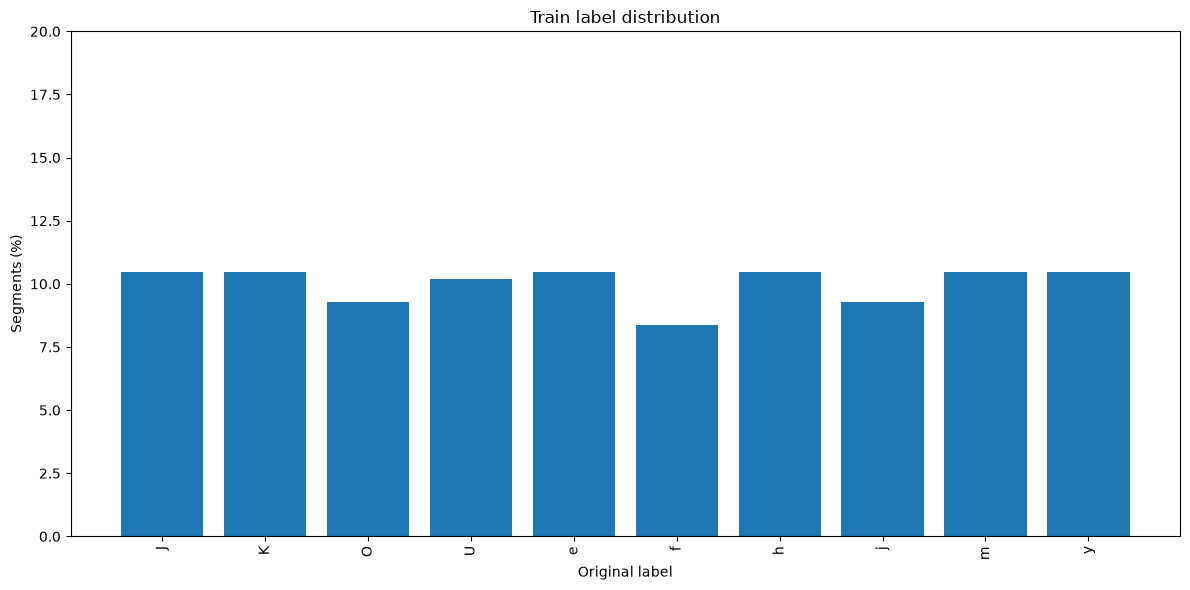

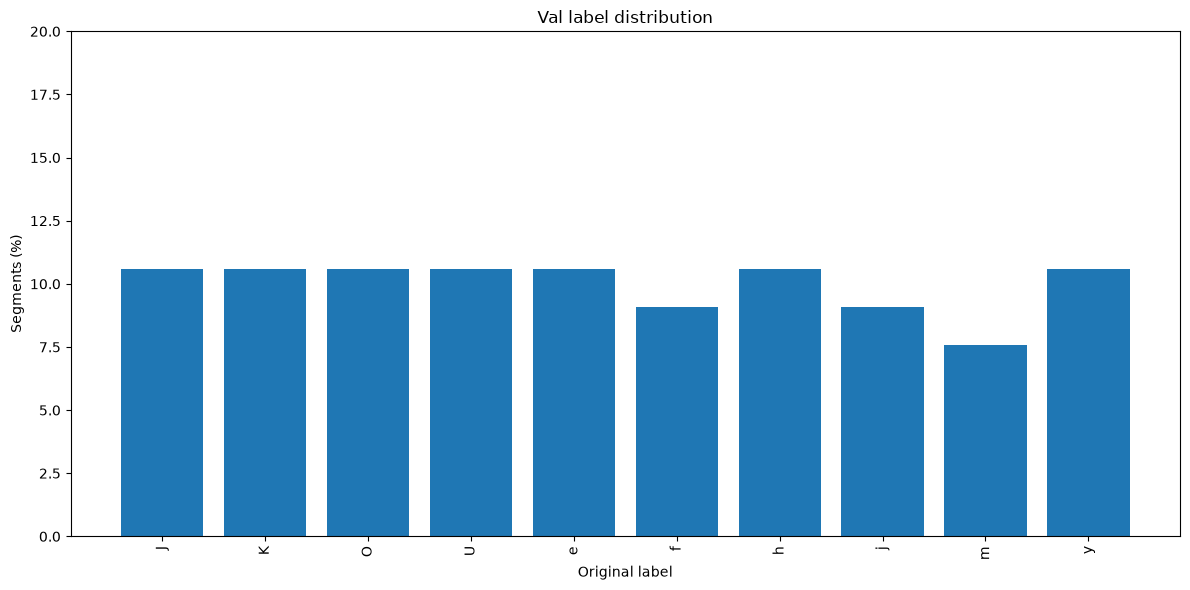

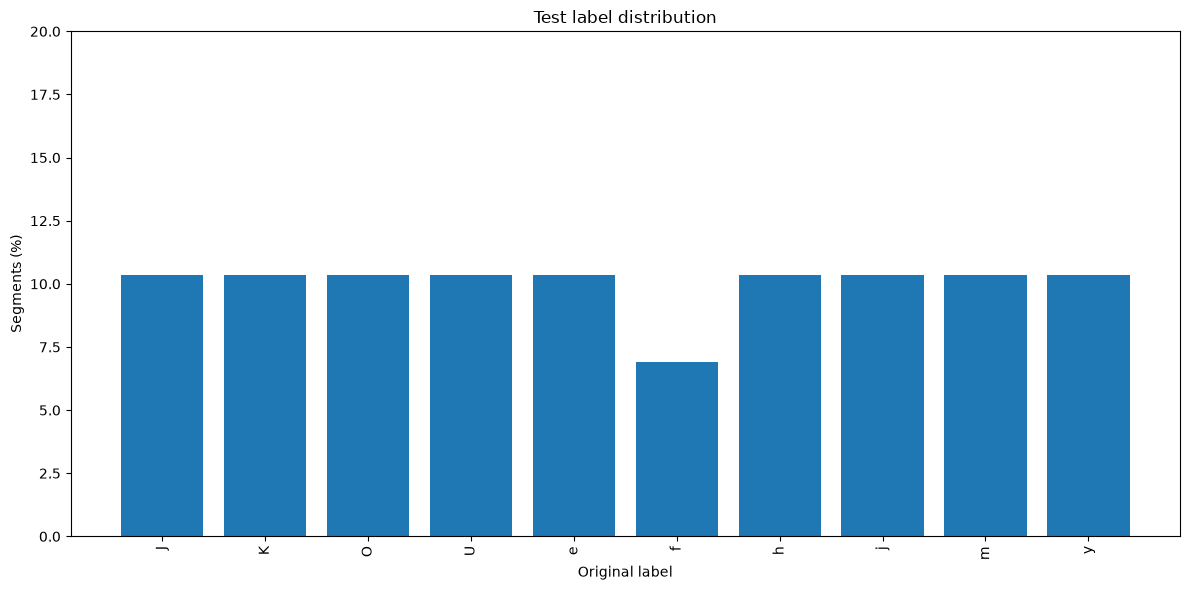

In [72]:
labels = list(class_to_idx)
split_datasets = {
    "Train": train_dataset,
    "Val": val_dataset,
    "Test": test_dataset,
}

percentage_by_split = {
    split_name: [
        100.0 * dataset.class_distribution.get(label, 0) / len(dataset)
        for label in labels
    ]
    for split_name, dataset in split_datasets.items()
}

print("Label | Train % | Val % | Test %")
for label_index, label in enumerate(labels):
    print(
        f"{label} | {percentage_by_split['Train'][label_index]!r} | "
        f"{percentage_by_split['Val'][label_index]!r} | "
        f"{percentage_by_split['Test'][label_index]!r}"
    )

for split_name, percentages in percentage_by_split.items():
    figure, axis = plt.subplots(figsize=(12, 6))
    axis.bar(labels, percentages)
    axis.set_title(f"{split_name} label distribution")
    axis.set_xlabel("Original label")
    axis.set_ylabel("Segments (%)")
    axis.tick_params(axis="x", rotation=90)
    axis.set_ylim(0, max(20.0, max(percentages, default=0.0)))
    figure.tight_layout()
    plt.show()

## Valid-frame 15-channel segment view

This deterministic view uses the selected dataset's `train_dataset[0]` directly, so it shows the configured post-encode representation without an additional plotting transform. Its horizontal axis is relative nominal sample-index time computed from the declared producer rate; acquisition timestamps are not loaded or inferred, and right-padding is excluded by the producer mask.

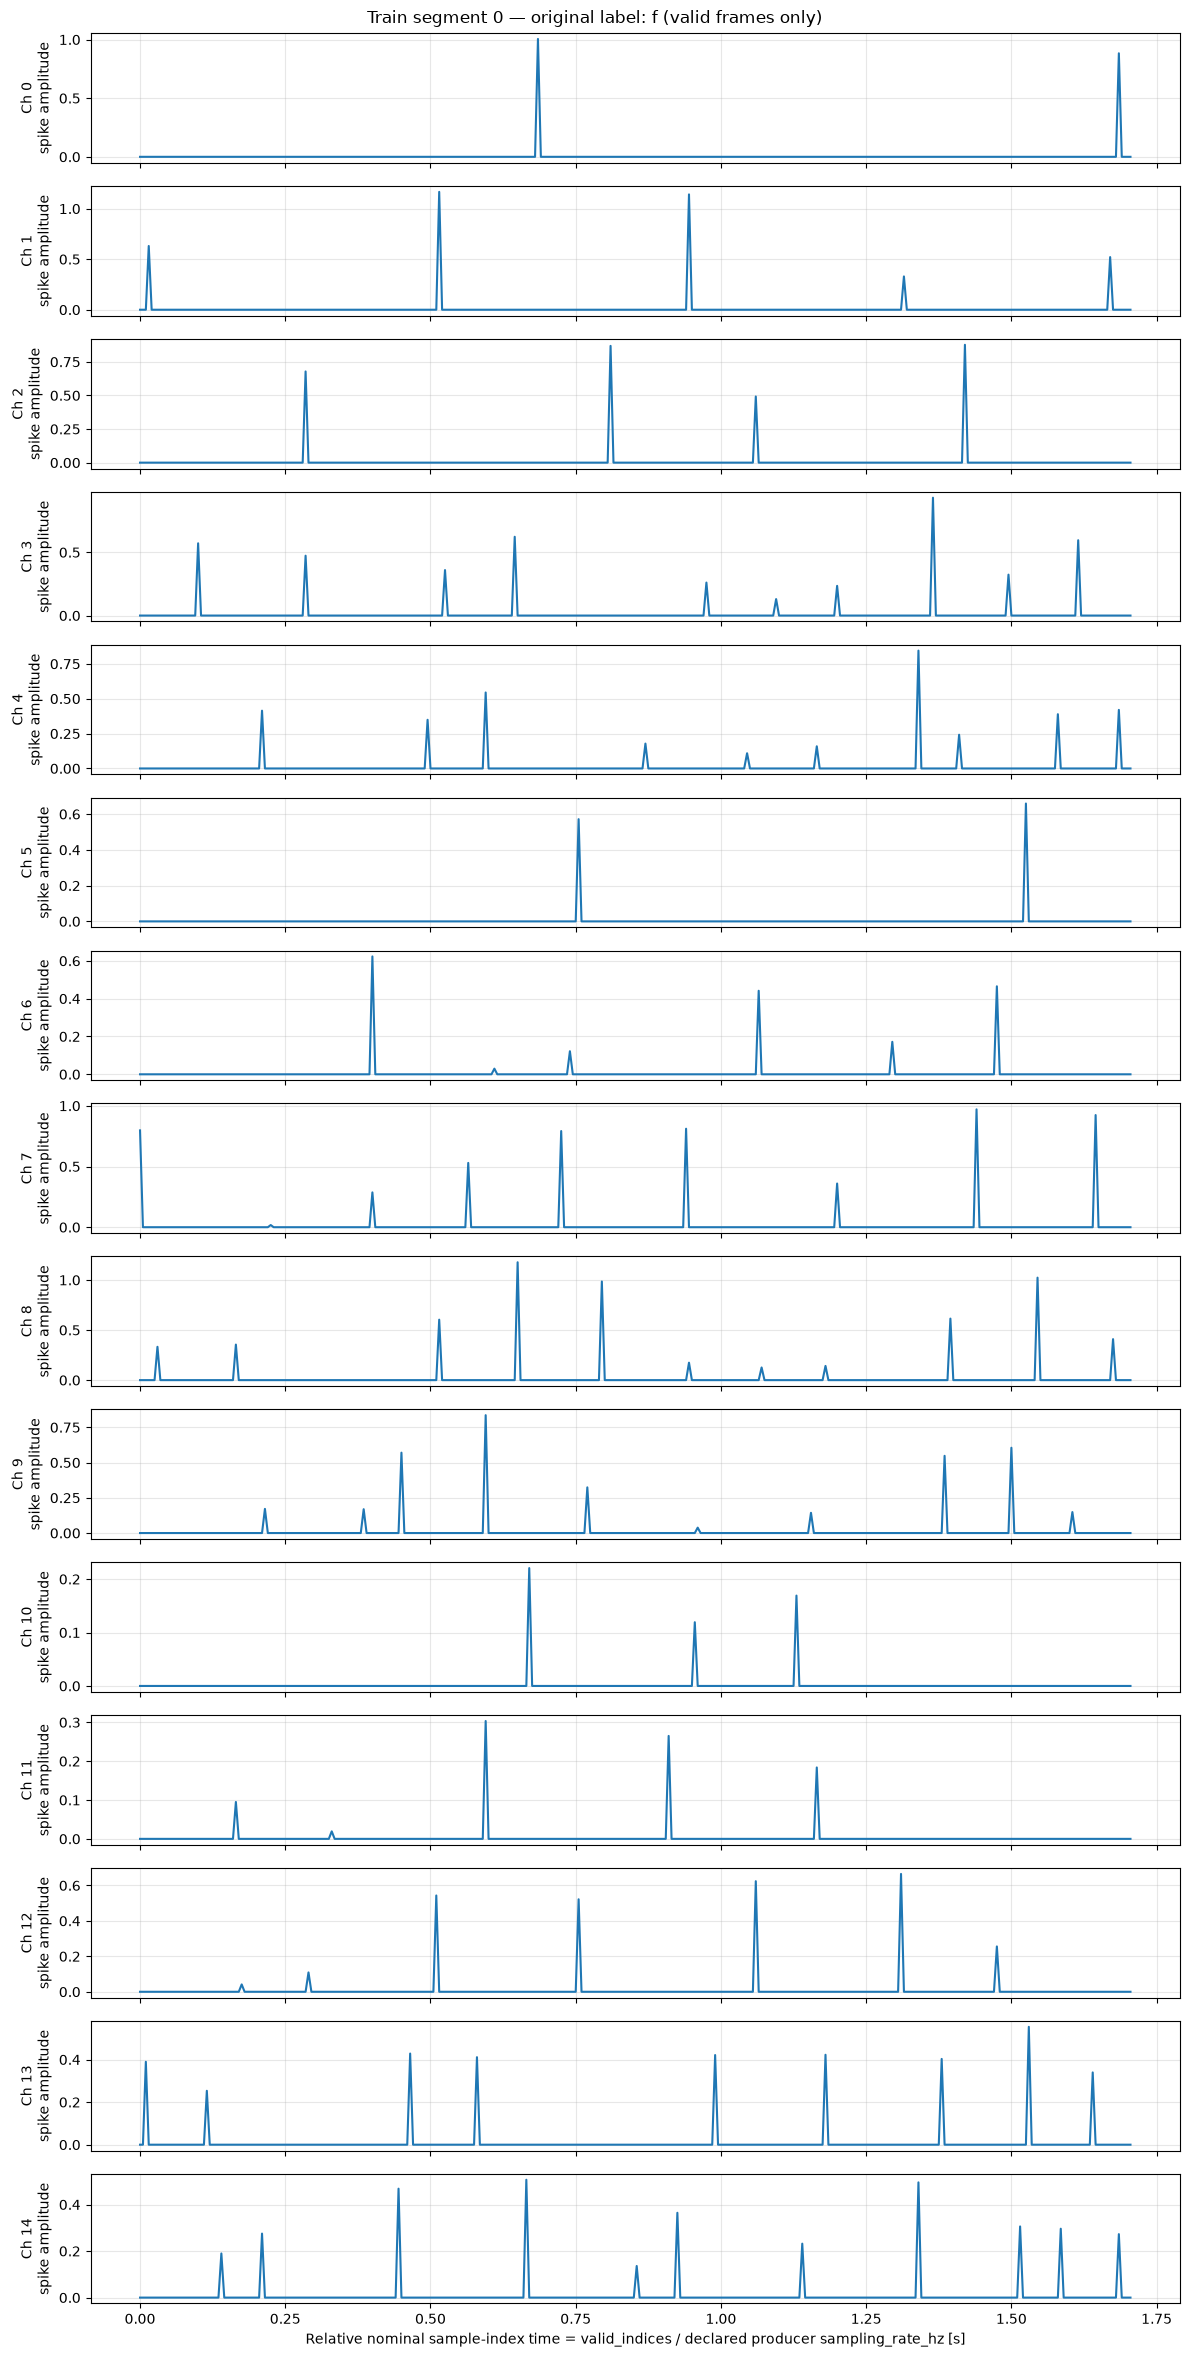

In [73]:
idx_to_class = {index: label for label, index in class_to_idx.items()}
segment_features, segment_label_index, valid_mask = train_dataset[0]
segment_label = idx_to_class[int(segment_label_index.item())]

valid_indices = np.flatnonzero(valid_mask.numpy())
relative_nominal_time_s = valid_indices / producer_metadata.sampling_rate_hz
segment_features_np = segment_features.numpy()

segment_figure, segment_axes = plt.subplots(
    nrows=15,
    ncols=1,
    sharex=True,
    figsize=(12, 24),
    squeeze=False,
)
for channel_index in range(15):
    axis = segment_axes[channel_index, 0]
    axis.plot(
        relative_nominal_time_s,
        segment_features_np[valid_indices, channel_index],
    )
    axis.set_ylabel(f"Ch {channel_index}\nspike amplitude")
    axis.grid(True, alpha=0.3)

segment_axes[-1, 0].set_xlabel(
    "Relative nominal sample-index time = valid_indices / declared producer sampling_rate_hz [s]"
)
segment_figure.suptitle(
    f"Train segment 0 — original label: {segment_label} (valid frames only)"
)
segment_figure.tight_layout(rect=(0, 0, 1, 0.99))
plt.show()

## Existing SynNet training loop

The training section reuses the Action0 model, masked loss, dataloaders, and epoch engine. Metrics and the strict-greater best validation state remain in memory for the result section.

In [74]:
from copy import deepcopy
from types import SimpleNamespace

import torch

from snn.action0_engine import run_epoch
from snn.action0_losses import MaskedCrossEntropySpkReg
from snn.train_action0 import (
    _create_dataloaders,
    _resolve_device,
    _set_random_seed,
    _validate_args,
)
from snn.utils_architectures import SynNet

if len(NEURONS_NETWORK) != 3:
    raise ValueError("NEURONS_NETWORK must contain exactly three SynNet layers")

training_args = SimpleNamespace(
    network_type="SynNet",
    sample_freq=SAMPLE_RATE,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    spike_regularization=SPIKE_REGULARIZATION,
    num_workers=0,
    max_train_batches=None,
    shift_syn=SHIFT_SYN,
    shift_mem=SHIFT_MEM,
    neurons_network=NEURONS_NETWORK,
    train_users=TRAIN_USERS,
    val_users=VAL_USERS,
    test_users=TEST_USERS,
)
_validate_args(training_args)

_set_random_seed(RANDOM_SEED)
device = _resolve_device(USE_GPU)
train_loader, val_loader, test_loader = _create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    random_seed=RANDOM_SEED,
    device=device,
)

preview_inputs, preview_labels, preview_valid_mask = next(iter(train_loader))
print(
    "Preview batch: inputs={}, labels={}, valid_mask={}".format(
        tuple(preview_inputs.shape),
        tuple(preview_labels.shape),
        tuple(preview_valid_mask.shape),
    )
)

model = SynNet(
    inputSize=15,
    outputSize=len(class_to_idx),
    hiddenSizes=NEURONS_NETWORK,
    sampleFreq=SAMPLE_RATE,
    shiftSyn=SHIFT_SYN,
    shiftMem=SHIFT_MEM,
).to(device)
criterion = MaskedCrossEntropySpkReg(
    spike_regularization=SPIKE_REGULARIZATION
)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

_HISTORY_METRICS = (
    "loss",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "mean_output_spikes",
    "mean_total_spikes",
    "zero_output_spike_fraction",
)
history = {
    "epochs": [],
    "train": {metric_name: [] for metric_name in _HISTORY_METRICS},
    "val": {metric_name: [] for metric_name in _HISTORY_METRICS},
}
best_state = None
best_epoch = -1
best_val_balanced_accuracy = float("-inf")

for epoch in range(NUM_EPOCHS):
    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        split="train",
        device=device,
        expected_num_classes=len(class_to_idx),
    )
    val_metrics = run_epoch(
        model,
        val_loader,
        criterion,
        split="val",
        device=device,
        expected_num_classes=len(class_to_idx),
    )

    history["epochs"].append(epoch)
    for split_name, split_metrics in (("train", train_metrics), ("val", val_metrics)):
        for metric_name in _HISTORY_METRICS:
            history[split_name][metric_name].append(float(split_metrics[metric_name]))

    validation_balanced_accuracy = float(val_metrics["balanced_accuracy"])
    if validation_balanced_accuracy > best_val_balanced_accuracy:
        best_val_balanced_accuracy = validation_balanced_accuracy
        best_epoch = epoch
        best_state = deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS}: "
        f"train loss={train_metrics['loss']:.6f}, "
        f"val balanced_accuracy={validation_balanced_accuracy:.6f}"
    )

if best_state is None:
    raise RuntimeError("training completed without a validation result")
for split_name in ("train", "val"):
    for metric_name in _HISTORY_METRICS:
        assert len(history[split_name][metric_name]) == NUM_EPOCHS
assert len(history["epochs"]) == NUM_EPOCHS
print(
    f"Best validation balanced accuracy: {best_val_balanced_accuracy:.6f} "
    f"at zero-based epoch {best_epoch}"
)

# Restore the strict-greater best checkpoint before every final evaluation.
model.load_state_dict(best_state, strict=True)
restored_best_state = {
    name: value.detach().clone() for name, value in model.state_dict().items()
}
restored_training_mode = model.training

# Final train evaluation intentionally uses split="val": this is uncapped,
# non-mutating evaluation and must never enter the optimizer path.
final_metrics = {
    "Train": run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=None,
        split="val",
        device=device,
        expected_num_classes=len(class_to_idx),
    ),
    "Validation": run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        split="val",
        device=device,
        expected_num_classes=len(class_to_idx),
    ),
    "Test": run_epoch(
        model,
        test_loader,
        criterion,
        optimizer=None,
        split="test",
        device=device,
        expected_num_classes=len(class_to_idx),
    ),
}
for name, value in model.state_dict().items():
    if not torch.equal(value, restored_best_state[name]):
        raise AssertionError(f"final evaluation mutated restored state: {name}")
model.train(restored_training_mode)

FINAL_METRICS = _HISTORY_METRICS
final_metrics_table = {
    metric_name: {
        split_name: float(split_metrics[metric_name])
        for split_name, split_metrics in final_metrics.items()
    }
    for metric_name in FINAL_METRICS
}

Preview batch: inputs=(256, 1024, 15), labels=(256,), valid_mask=(256, 1024)
Epoch 1/30: train loss=2.356349, val balanced_accuracy=0.114286
Epoch 2/30: train loss=2.328277, val balanced_accuracy=0.100000
Epoch 3/30: train loss=2.309586, val balanced_accuracy=0.100000
Epoch 4/30: train loss=2.315705, val balanced_accuracy=0.085714
Epoch 5/30: train loss=2.303901, val balanced_accuracy=0.114286
Epoch 6/30: train loss=2.304060, val balanced_accuracy=0.157143
Epoch 7/30: train loss=2.302649, val balanced_accuracy=0.142857
Epoch 8/30: train loss=2.302654, val balanced_accuracy=0.114286
Epoch 9/30: train loss=2.303292, val balanced_accuracy=0.100000
Epoch 10/30: train loss=2.303127, val balanced_accuracy=0.100000
Epoch 11/30: train loss=2.302933, val balanced_accuracy=0.085714
Epoch 12/30: train loss=2.302716, val balanced_accuracy=0.071429
Epoch 13/30: train loss=2.302609, val balanced_accuracy=0.057143
Epoch 14/30: train loss=2.302437, val balanced_accuracy=0.071429
Epoch 15/30: train los

## Training results

Training and validation metrics across epochs. The best epoch is selected using validation balanced accuracy.

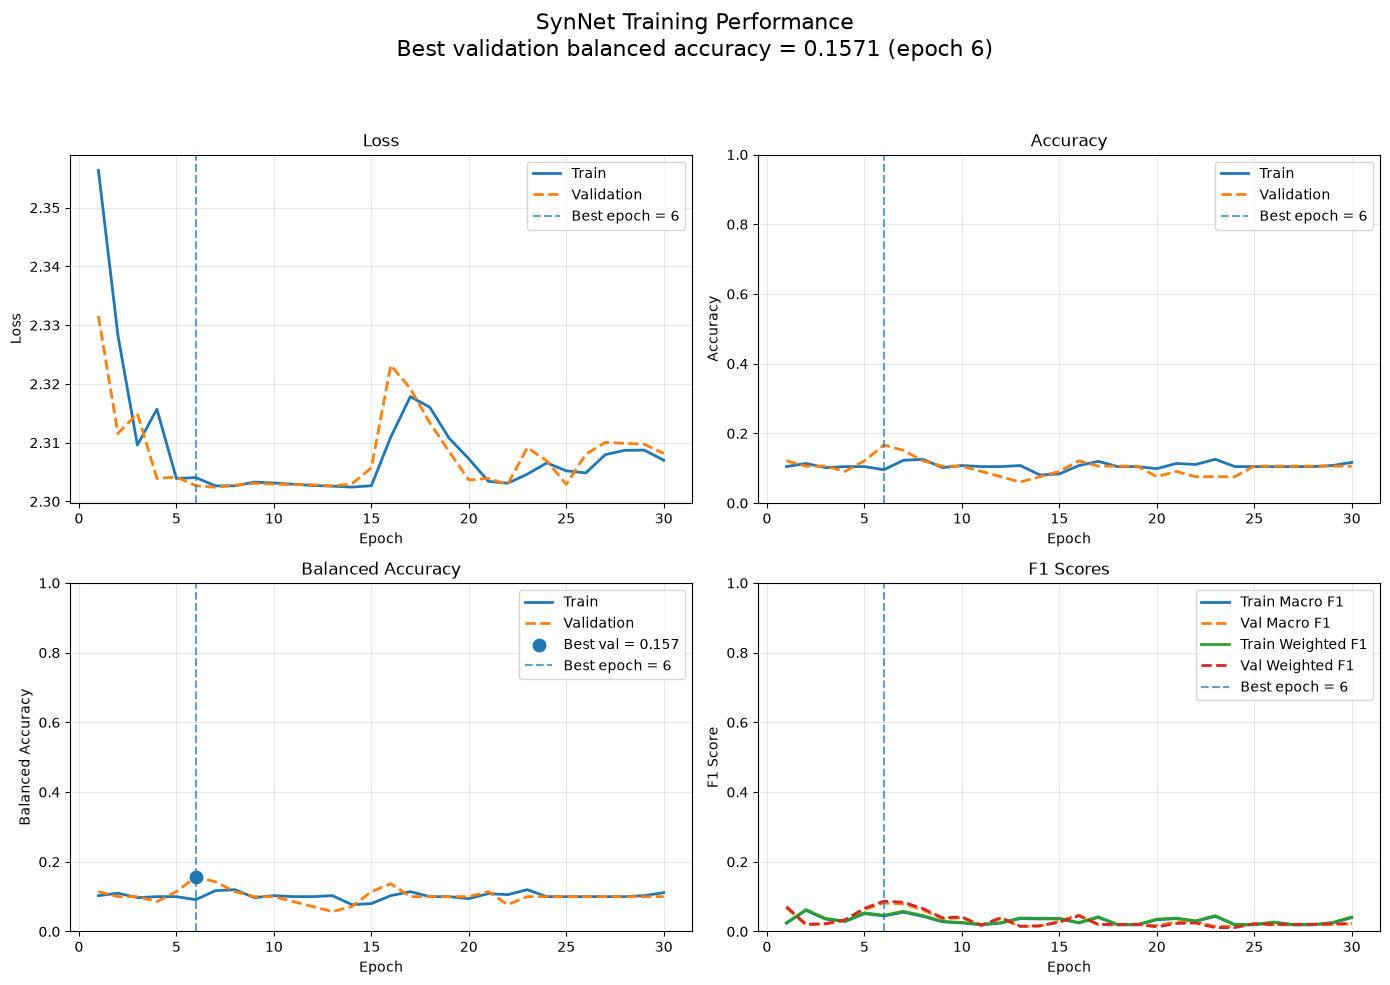

Figure saving disabled (SAVE_FIGURES=False).


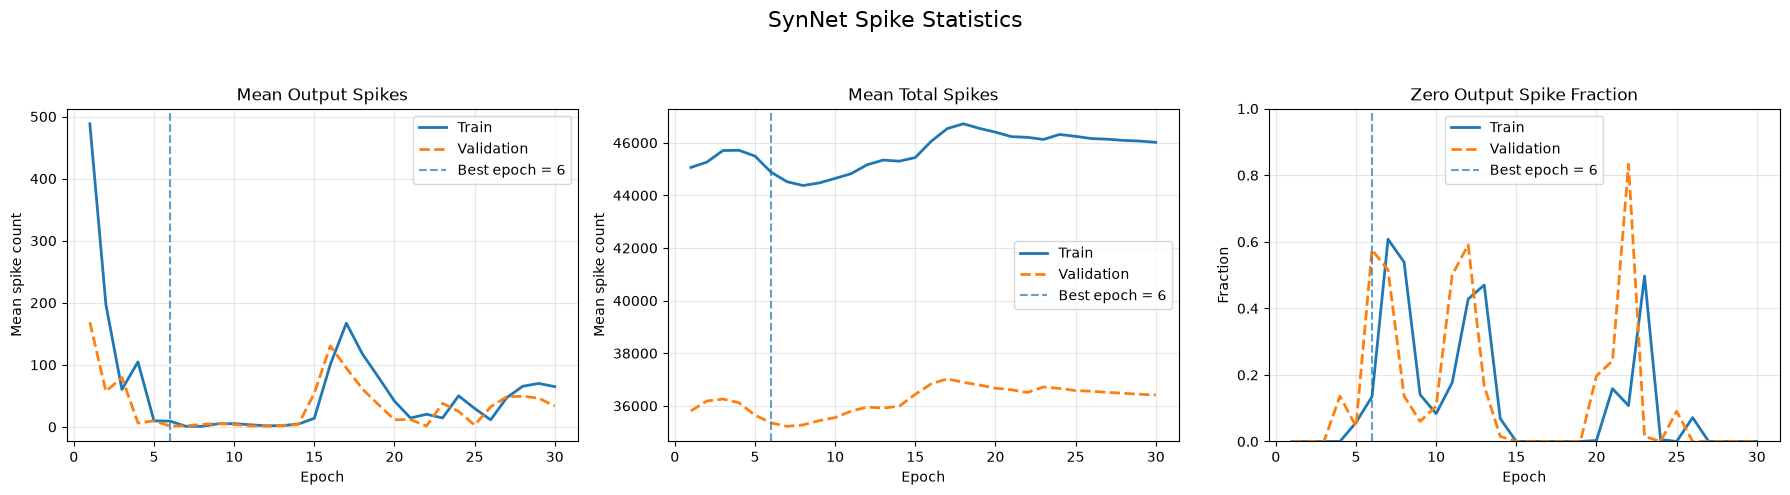

Figure saving disabled (SAVE_FIGURES=False).

FINAL BEST-MODEL METRICS
Metric | Train | Validation | Test
--- | ---: | ---: | ---:
loss | 2.302680 | 2.302668 | 2.302664
accuracy | 0.119760 | 0.166667 | 0.068966
balanced_accuracy | 0.114286 | 0.157143 | 0.066667
macro_f1 | 0.052043 | 0.082062 | 0.029338
weighted_f1 | 0.054536 | 0.087036 | 0.030350
mean_output_spikes | 0.916168 | 1.424242 | 0.982759
mean_total_spikes | 44547.140719 | 35356.257576 | 47547.155172
zero_output_spike_fraction | 0.601796 | 0.575758 | 0.551724

EXPERIMENT PROVENANCE
POST_ENCODE_TRANSFORM: 'AbsRectify'
DATASET_VARIANT: 'lowpass'
Selected pipeline root: /home/ted/project/writingring-viz/outputs/action0_rectified
Selected padded root: /home/ted/project/writingring-viz/outputs/action0_rectified/low-pass/label/segmentation_padded
Sample rate (Hz): 200
LABEL_SELECTION_SEED: 12345
NUM_SELECTED_LABELS: 10
Selected labels: ['J', 'K', 'O', 'U', 'e', 'f', 'h', 'j', 'm', 'y']
Selected class mapping: {'J': 0, 'K': 1, 'O': 2

In [75]:
# ============================================================
# Training result visualization
# ============================================================

epochs = np.asarray(history["epochs"]) + 1
best_epoch_display = best_epoch + 1

# Figures are always displayed; files are written only when explicitly enabled.
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def mark_best_epoch(axis):
    """Mark the checkpoint selected by validation balanced accuracy."""
    axis.axvline(
        best_epoch_display,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        label=f"Best epoch = {best_epoch_display}",
    )


# ============================================================
# Figure 1: Classification performance
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

ax = axes[0, 0]

ax.plot(
    epochs,
    history["train"]["loss"],
    linewidth=2,
    label="Train",
)

ax.plot(
    epochs,
    history["val"]["loss"],
    linewidth=2,
    linestyle="--",
    label="Validation",
)

mark_best_epoch(ax)

ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

ax = axes[0, 1]

ax.plot(
    epochs,
    history["train"]["accuracy"],
    linewidth=2,
    label="Train",
)

ax.plot(
    epochs,
    history["val"]["accuracy"],
    linewidth=2,
    linestyle="--",
    label="Validation",
)

mark_best_epoch(ax)

ax.set_title("Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()


# ------------------------------------------------------------
# Balanced accuracy
# ------------------------------------------------------------

ax = axes[1, 0]

ax.plot(
    epochs,
    history["train"]["balanced_accuracy"],
    linewidth=2,
    label="Train",
)

ax.plot(
    epochs,
    history["val"]["balanced_accuracy"],
    linewidth=2,
    linestyle="--",
    label="Validation",
)

# Explicitly mark the best validation point
ax.scatter(
    best_epoch_display,
    history["val"]["balanced_accuracy"][best_epoch],
    s=80,
    zorder=5,
    label=(
        f"Best val = "
        f"{history['val']['balanced_accuracy'][best_epoch]:.3f}"
    ),
)

mark_best_epoch(ax)

ax.set_title("Balanced Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced Accuracy")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()


# ------------------------------------------------------------
# F1 scores
# ------------------------------------------------------------

ax = axes[1, 1]

ax.plot(
    epochs,
    history["train"]["macro_f1"],
    linewidth=2,
    label="Train Macro F1",
)

ax.plot(
    epochs,
    history["val"]["macro_f1"],
    linewidth=2,
    linestyle="--",
    label="Val Macro F1",
)

ax.plot(
    epochs,
    history["train"]["weighted_f1"],
    linewidth=2,
    label="Train Weighted F1",
)

ax.plot(
    epochs,
    history["val"]["weighted_f1"],
    linewidth=2,
    linestyle="--",
    label="Val Weighted F1",
)

mark_best_epoch(ax)

ax.set_title("F1 Scores")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1 Score")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()


fig.suptitle(
    (
        "SynNet Training Performance\n"
        f"Best validation balanced accuracy = "
        f"{best_val_balanced_accuracy:.4f} "
        f"(epoch {best_epoch_display})"
    ),
    fontsize=16,
)

fig.tight_layout(rect=(0, 0, 1, 0.94))

plt.show()

if SAVE_FIGURES:
    performance_path = FIGURE_DIR / "training_performance.png"
    fig.savefig(performance_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {performance_path}")
else:
    print("Figure saving disabled (SAVE_FIGURES=False).")


# ============================================================
# Figure 2: SNN spike statistics
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Mean output spikes
# ------------------------------------------------------------

ax = axes[0]

ax.plot(
    epochs,
    history["train"]["mean_output_spikes"],
    linewidth=2,
    label="Train",
)

ax.plot(
    epochs,
    history["val"]["mean_output_spikes"],
    linewidth=2,
    linestyle="--",
    label="Validation",
)

mark_best_epoch(ax)

ax.set_title("Mean Output Spikes")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean spike count")
ax.grid(True, alpha=0.3)
ax.legend()


# ------------------------------------------------------------
# Mean total spikes
# ------------------------------------------------------------

ax = axes[1]

ax.plot(
    epochs,
    history["train"]["mean_total_spikes"],
    linewidth=2,
    label="Train",
)

ax.plot(
    epochs,
    history["val"]["mean_total_spikes"],
    linewidth=2,
    linestyle="--",
    label="Validation",
)

mark_best_epoch(ax)

ax.set_title("Mean Total Spikes")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean spike count")
ax.grid(True, alpha=0.3)
ax.legend()


# ------------------------------------------------------------
# Zero-output-spike fraction
# ------------------------------------------------------------

ax = axes[2]

ax.plot(
    epochs,
    history["train"]["zero_output_spike_fraction"],
    linewidth=2,
    label="Train",
)

ax.plot(
    epochs,
    history["val"]["zero_output_spike_fraction"],
    linewidth=2,
    linestyle="--",
    label="Validation",
)

mark_best_epoch(ax)

ax.set_title("Zero Output Spike Fraction")
ax.set_xlabel("Epoch")
ax.set_ylabel("Fraction")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()


fig.suptitle(
    "SynNet Spike Statistics",
    fontsize=16,
)

fig.tight_layout(rect=(0, 0, 1, 0.93))

plt.show()

if SAVE_FIGURES:
    spike_path = FIGURE_DIR / "spike_statistics.png"
    fig.savefig(spike_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {spike_path}")
else:
    print("Figure saving disabled (SAVE_FIGURES=False).")


# ============================================================
# Final non-mutating metrics table and experiment provenance
# ============================================================

print()
print("FINAL BEST-MODEL METRICS")
print("Metric | Train | Validation | Test")
print("--- | ---: | ---: | ---:")
for metric_name in FINAL_METRICS:
    print(
        f"{metric_name} | "
        f"{final_metrics_table[metric_name]['Train']:.6f} | "
        f"{final_metrics_table[metric_name]['Validation']:.6f} | "
        f"{final_metrics_table[metric_name]['Test']:.6f}"
    )

print()
print("EXPERIMENT PROVENANCE")
print(f"POST_ENCODE_TRANSFORM: {POST_ENCODE_TRANSFORM!r}")
print(f"DATASET_VARIANT: {DATASET_VARIANT!r}")
print(f"Selected pipeline root: {PIPELINE_ROOT}")
print(f"Selected padded root: {segmentation_root}")
print(f"Sample rate (Hz): {producer_metadata.sampling_rate_hz:g}")
print(f"LABEL_SELECTION_SEED: {LABEL_SELECTION_SEED}")
print(f"NUM_SELECTED_LABELS: {NUM_SELECTED_LABELS}")
print(f"Selected labels: {selected_labels}")
print(f"Selected class mapping: {class_to_idx}")
print(f"Best epoch (1-based): {best_epoch_display}")
print(
    f"Best validation balanced accuracy: {best_val_balanced_accuracy:.6f}"
)